In [36]:
import numpy as np
from scipy import sparse # Use sparse matrix for A to be able to use greater values of m
import matplotlib.pyplot as plt

# Only show numbers with 4 decimal points in print
np.set_printoptions(
    formatter={'float_kind': lambda x: f"{x:.4f}"}
)


# Variant 1

Implement a Python function to solve the **Poisson problem** on a square domain with homogeneous Dirichlet boundary conditions, using the **5-point finite difference Laplacian**:

$$
\nabla^2 u = f,
\qquad (x, y) \in [a, b] \times [c, d],
$$

with
$$
u(x,c) = g_c(x), \quad u(x, d) = g_d(x), \quad u(a,y) = g_a(y), \quad u(b,y) = g_b(y).
$$

### (a) Implement the solver


In [37]:

def poisson_generalized(m_x, m_y, a, b, c, d, f= None, g = None):
    """
    Solve the 2D Poisson equation:
        ∇²u = f,   (x,y) ∈ [a,b] × [c,d],
        u = g on the boundary.

        We assume g is continue in the vertex, otherwise the constraint on x has priority. That is,
        
        u(a, c) = g_a(c)
        u(a, d) = g_a(d)
        
        u(b, c) = g_b(c)
        u(b, d) = g_b(d)

        
        
    Parameters
    ----------
    m_x, m_y : int
        Number of interior grid points in x and y respectively.
    
    a,b,c,d: float
        limits of the rectangular domain
    
    f: function
        Function of the equation. Defaults to  -2 sin(x) sin(y)
            
    g: dictionary of functions with keys "a", "b", "c" and "d".
        BCs. Defaults to all the 4 equal to 0

    Returns
    -------
    X, Y : 1D ndarrays
        Meshgrid of all grid points including boundaries.
    U : 2D ndarray
        Numerical solution at all grid points.
    """
    
        
        
    # Step 1: Discretize domain [0, 2π] × [0, 2π]
    
    # In this case X and Y are the same, but not in general
    X = np.linspace(start=a, stop=b, num=m_x+2) # In total m_x+2 points
    Y = np.linspace(start=c, stop=d, num=m_y+2) # In total m_y+2 points
    
    hx = X[1]-X[0] # distance between 2 consecutive points in X
    hy = Y[1]-Y[0] # distance between 2 consecutive points in Y
    # Step 2: Build sparse matrix A for the 5-point Laplacian
    
   
#   We will use the index k = (m_x)*j + i for i = 0,...,m_x-1, j = 0,...,m_y-1
#   So the range of k is k = 0,..., m_x*m_y
    A = np.zeros((m_x*m_y,m_x*m_y)) # first index is value of k where the eqn is centered, second index are the elements


    for j in range(m_y): # 0,...,m_y-1: is in our notation 1,...,m_y
        for i in range(m_x): # 0,...,m_x-1: is in our notation 1,...,m_x
            
            # BUG: denominators are h**2, not h
            
            # index of u in the vector of length m**2 (BCs = 0)
            k = m_x*j + i # k(i,j)
            
            # Set entries of A:
            
            # (i,j)
            A[k,k] = -2/hx**2 - 2/hy**2
            
            # (i-1, j) if not in boundary
            if i>0:  # k(i-1, j) = m_x*j +i-1 = k(i,j) -1
                A[k, k-1] = 1/hx**2
                
                
            # (i+1, j) if not in boundary
            if i<m_x-1: # k(i+1, j) = m_x*j +i+1 = k(i,j) +1
                A[k, k+1] = 1/hx**2
        
            # (i, j-1) if not in boundary
            if j>0: # k(i, j-1) = m_x*(j-1) +i = k(i,j) -m_x
                A[k, k-m_x] = 1/hy**2
                
                
            # (i, j+1) if not in boundary
            if j<m_y-1: # k(i, j+1) = m_x*(j+1) +i = k(i,j) +m_x
                A[k, k+m_x] = 1/hy**2


    # Finally we use sparse to use an sparse array instead of a matrix
    A = sparse.csr_matrix(A)
    
    
    # Step 3: Assemble RHS vector
    if f == None:
        f = lambda x,y: -2*np.sin(x)*np.sin(y)
    
        
    if g == None: # We set g = 0 in the borders
        
        # BCs
        
        g = {
            "a": lambda y: 0,
            "b": lambda y: 0,
            "c": lambda x: 0,
            "d": lambda x: 0
        }
    
    rhs = np.zeros(m_x*m_y)
    
    for j in range(m_y):
        y = Y[j+1] # Y includes boundary points at 0 and m+1, so we take values at 1,...,m 
        
        for i in range(m_x):
            
            x = X[i+1] # X includes boundary points at 0 and m+1, so we take values at 1,...,m 
            
            k = m_x*j+i
                        
            rhs[k] = f(x, y) # Base rhs with no BCs
            
            # ADD BCs
            
            if i == 0: # In this case would it is centered with our notation in (1, j) so u_0j = g_a(j) appears
                rhs[k] -= g["a"](y)/hx**2
                
            elif i == m_x-1: # In this case would it is centered with our notation in (m_x, j) so u_(mx+1) j = g_b(j) appears
                rhs[k] -= g["b"](y)/hx**2
                
            if j == 0: # In this case would it is centered with our notation in (i, 1) so u_i0 = g_c(i) appears
                rhs[k] -= g["c"](y)/hy**2
                            
            elif j == m_y-1: # In this case would it is centered with our notation in (i, m_x) so u_i (my+1) = g_d(j) appears
                rhs[k] -= g["d"](y)/hy**2
            
    
    # Step 4: Solve linear system AU = F
    # spsolve optimized to solve sparse matrices
    U_vector = sparse.linalg.spsolve(A, rhs) # Vector of length m_x*m_y (the index is k = m_x*j+i)
    
    # Step 5: Reconstruct solution including boundary values

    U = np.zeros((m_x+2, m_y+2)) # uij for i,j=0,..., m+1
    
    # BCs:
    U[:, 0] = g["c"](X)
    U[:, -1] = g["d"](X) # Column m_y+1
    
    # Overwrite vertex with conds on x (these have priority)
    U[0, :] = g["a"](Y)
    U[-1, :] = g["b"](Y) # row m_x+1
    
   
    # Inner points:
    for j in range(m_y):
        
        for i in range(m_x):
            
            k = m_x*j + i # BUG: had written m*j+1 
            
            U[i+1, j+1] =  U_vector[k]# Only change values for i = 1,...,m_x; j= 1,...,m_y.
            
    
    return X, Y, U

Compare if the code is the same than Task 5 for that problem:

In [38]:
def dist_l2(u_approx, u_exact, h_x, h_y):
    """Returns the normalized l2 norm of the error. 
    
        The real l2 norm would be
            np.sqrt(np.sum((u_approx-u_exact)**2))
        
        The normalized one is
            np.sqrt(h_x * h_y * np.sum((u_approx-u_exact)**2))
            
        with h_x, h_y the size step in x and y coordinates respectively.

    Args:
        u_approx (1D ndarray): Approximation of u
        u_exact (1D ndarray): Exact value of u
        h_x (float): step size in x
        h_y (float): step size in y

    Returns:
        1D ndarray: L2 Error
    """
    return np.sqrt(h_x * h_y * np.sum((u_approx-u_exact)**2))

def dist_linf(u_approx, u_exact):
    return np.max(np.abs(u_approx - u_exact))

def apply_exact(X, Y, u):
    """Apply u to the grid

    Args:
        X, Y : 1D ndarrays
                Meshgrid of all grid points including boundaries.
        u (function): function to evaluate
        
    Returns
        U: 2D ndarrays
                Evaluation of U in the grid
    """
    
    # We may have different lengths
    n = len(X)
    m = len(Y)
    
    U = np.zeros((n, m))
    
    for i in range(n):
        x = X[i]
        for j in range(m):
            y = Y[j]
            U[i,j] = u(x, y)
            
    
    # Also can use np.meshgrid in the following way:
    #     XX, YY = np.meshgrid(X, Y, indexing="ij")
    #     U = u (XX, YY)
    
    return U

### Check if default for g works:

U = [[0.0000 0.0000 0.0000 0.0000]
 [0.0000 1.0966 -1.0966 0.0000]
 [0.0000 -1.0966 1.0966 0.0000]
 [0.0000 0.0000 0.0000 0.0000]]
U = [[0.0000 0.0000 0.0000 0.0000 0.0000 0.0000]
 [0.0000 1.0336 0.6388 -0.6388 -1.0336 0.0000]
 [0.0000 0.6388 0.3948 -0.3948 -0.6388 0.0000]
 [0.0000 -0.6388 -0.3948 0.3948 0.6388 0.0000]
 [0.0000 -1.0336 -0.6388 0.6388 1.0336 0.0000]
 [0.0000 0.0000 0.0000 0.0000 0.0000 0.0000]]
U = [[0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000]
 [0.0000 0.4304 0.6594 0.5798 0.2290 -0.2290 -0.5798 -0.6594 -0.4304
  0.0000]
 [0.0000 0.6594 1.0102 0.8884 0.3508 -0.3508 -0.8884 -1.0102 -0.6594
  0.0000]
 [0.0000 0.5798 0.8884 0.7812 0.3085 -0.3085 -0.7812 -0.8884 -0.5798
  0.0000]
 [0.0000 0.2290 0.3508 0.3085 0.1218 -0.1218 -0.3085 -0.3508 -0.2290
  0.0000]
 [0.0000 -0.2290 -0.3508 -0.3085 -0.1218 0.1218 0.3085 0.3508 0.2290
  0.0000]
 [0.0000 -0.5798 -0.8884 -0.7812 -0.3085 0.3085 0.7812 0.8884 0.5798
  0.0000]
 [0.0000 -0.6594 -1.0102 -0.8884 -0

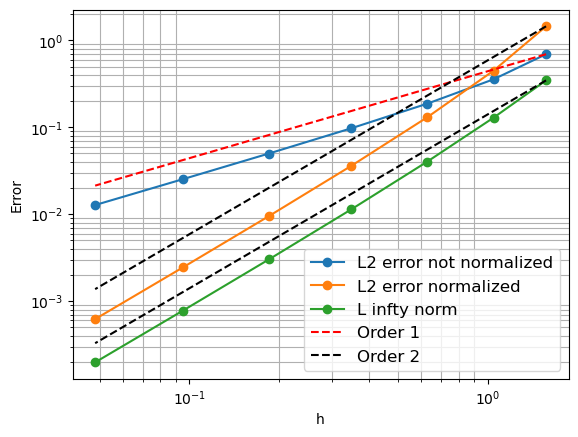

In [39]:



m_list = [2**k for k in range(1,8)] # 2, 4,..., 256. To be able to use greater values of m implement A using sparse directly
# Observe that A contains m**4 elements, so for m=32 A has 1_048_576,
# and 16_777_216 for m=64 (which after 10 minutes does not finish)

h_list = np.array([2*np.pi / (m+2) for m in m_list]) # m inner points, so m+2 in total i. e. 2*pi = (m+2)*h

u = lambda x, y: np.sin(x)*np.sin(y)

error_l2 = []
error_l2_normalized = []
error_linf = []
for m in m_list:
    X, Y, U = poisson_generalized(m_x=m, m_y=m, a=0, b=2*np.pi, c=0, d= 2*np.pi)
    # print(f"X = {X}")
    # print(f"Y = {Y}")
    
    print(f"U = {U}")
    U_exact = apply_exact(X, Y, u)
    
    # print(f"U_exact = {U_exact}")
    error_l2.append(dist_l2(U, U_exact, h_x= 1, h_y = 1)) # l2 error without the normalization
    error_l2_normalized.append(dist_l2(U, U_exact, h_x= X[1]-X[0], h_y = Y[1]-Y[0]))
    error_linf.append(dist_linf(U, U_exact))

# print(f"error_l2_normalized = {error_l2_normalized}")
# print(h_list)
plt.loglog(h_list, error_l2, "o-", label = "L2 error not normalized")
plt.loglog(h_list, error_l2_normalized, "o-", label = "L2 error normalized")
plt.loglog(h_list, error_linf, "o-", label = "L infty norm")

plt.loglog(h_list, (error_l2[0]/h_list[0]**1)*h_list**1, "r--", label = "Order 1")
plt.loglog(h_list, (error_l2_normalized[0]/h_list[0]**2)*h_list**2, "k--", label = "Order 2")
plt.loglog(h_list, (error_linf[0]/h_list[0]**2)*h_list**2, "k--")

plt.legend(fontsize=12, loc="best")
plt.xlabel("h")
plt.ylabel("Error")
plt.grid(True, which="minor")

plt.show()

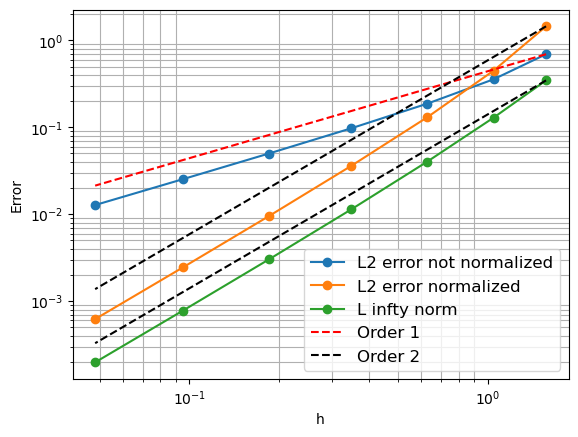

In [40]:

import matplotlib.pyplot as plt
# # Only show numbers with 4 decimal points in print
# np.set_printoptions(
#     formatter={'float_kind': lambda x: f"{x:.4f}"}
# )


m_list = [2**k for k in range(1,8)] # 2, 4,..., 256. To be able to use greater values of m implement A using sparse directly
# Observe that A contains m**4 elements, so for m=32 A has 1_048_576,
# and 16_777_216 for m=64 (which after 10 minutes does not finish)

h_list = np.array([2*np.pi / (m+2) for m in m_list]) # m inner points, so m+2 in total i. e. 2*pi = (m+2)*h

u = lambda x, y: np.sin(x)*np.sin(y)

error_l2 = []
error_l2_normalized = []
error_linf = []


g = {
    "a": lambda y: 0,
    "b": lambda y: 0,
    "c": lambda x: 0,
    "d": lambda x: 0
}

for m in m_list:
    X, Y, U = poisson_generalized(m_x=m, m_y=m, a=0, b=2*np.pi, c=0, d= 2*np.pi, g=g)
    # print(f"X = {X}")
    # print(f"Y = {Y}")
    
    # print(f"U = {U}")
    U_exact = apply_exact(X, Y, u)
    
    # print(f"U_exact = {U_exact}")
    error_l2.append(dist_l2(U, U_exact, h_x= 1, h_y = 1)) # l2 error without the normalization
    error_l2_normalized.append(dist_l2(U, U_exact, h_x= X[1]-X[0], h_y = Y[1]-Y[0]))
    error_linf.append(dist_linf(U, U_exact))

# print(f"error_l2_normalized = {error_l2_normalized}")
# print(h_list)
plt.loglog(h_list, error_l2, "o-", label = "L2 error not normalized")
plt.loglog(h_list, error_l2_normalized, "o-", label = "L2 error normalized")
plt.loglog(h_list, error_linf, "o-", label = "L infty norm")

plt.loglog(h_list, (error_l2[0]/h_list[0]**1)*h_list**1, "r--", label = "Order 1")
plt.loglog(h_list, (error_l2_normalized[0]/h_list[0]**2)*h_list**2, "k--", label = "Order 2")
plt.loglog(h_list, (error_linf[0]/h_list[0]**2)*h_list**2, "k--")

plt.legend(fontsize=12, loc="best")
plt.xlabel("h")
plt.ylabel("Error")
plt.grid(True, which="minor")

plt.show()

## Plots

Now I am going to plot the results for a different BC.

In [41]:
def plot_surface(X, Y, U):
    
    fig = plt.figure() # fig saves the figure in case we want to do something
    ax = plt.axes(projection = "3d")

    X_grid, Y_grid = np.meshgrid(X, Y, indexing="ij")

    ax.plot_surface(X_grid, Y_grid, U, cmap = "viridis") # ax.plot3D plots lines between points, not the surface. 
    # Use it for curves
        

    plt.show()

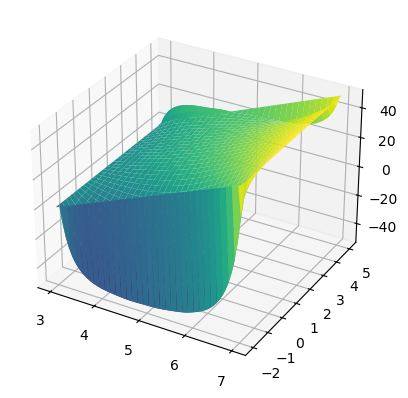

In [42]:

# I am going to use a tilted plane as base 
a = 3
b = 7
c =-2
d = 5

# First example
f = lambda x, y: x * y * np.sin(x**2+y**2)
slope = 50
g = {
    "a": lambda y: 0,
    "b": lambda y: slope,
    "c": lambda x: slope*(x-a)/(b-a),
    "d": lambda x: slope*(x-a)/(b-a)
}


m_x = 64
m_y = 32

X, Y, U = poisson_generalized(m_x, m_y, a, b, c, d, f = f, g=g)

fig = plt.figure()
ax = plt.axes(projection = "3d")

X_grid, Y_grid = np.meshgrid(X, Y, indexing="ij")

ax.plot_surface(X_grid, Y_grid, U, cmap = "viridis") # ax.plot3D plots lines between points, not the surface. 
# Use it for curves

plt.show()

What if we want different POVs?

In [43]:
        
def plot_surface_perspectives(X, Y, U, perspective):
    
    number_axes = np.ceil(np.sqrt(len(perspective))).astype(int) # axes will form an square with this number of axes per side
    # print(f"number_axes = {number_axes}")
    
    # Grid to be able to plot
    X_grid, Y_grid = np.meshgrid(X, Y, indexing="ij")
    
    # figsize by default uses inches (which I don't use), so change to cm
    cm = 1/2.54 # 1 inch is 2.54 cm
    # I will leave 10x10 cm to each axis
    fig = plt.figure(figsize = (number_axes*10*cm, number_axes*10*cm))
        
    
    # Divide the figure in a square with same number of axes in each row and column
    
    
    
    i = 1 # Number of the axis we are placing
    for (height, angle) in perspective:
        # instead of using i this way we can use:
        # for i, (elev, azim) in enumerate(perspective, 1) and erase i+=1
        
        ax = fig.add_subplot(number_axes, number_axes, i, projection = "3d") 
        i += 1
        
        ax.plot_surface(X_grid, Y_grid, U, cmap = "viridis") # Plot surface
        
        # Set view point
        ax.view_init(elev = height, azim = angle)
        
        # Set labels
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("u")
        
    plt.tight_layout() # Controls spacing between axes
    plt.show()
        

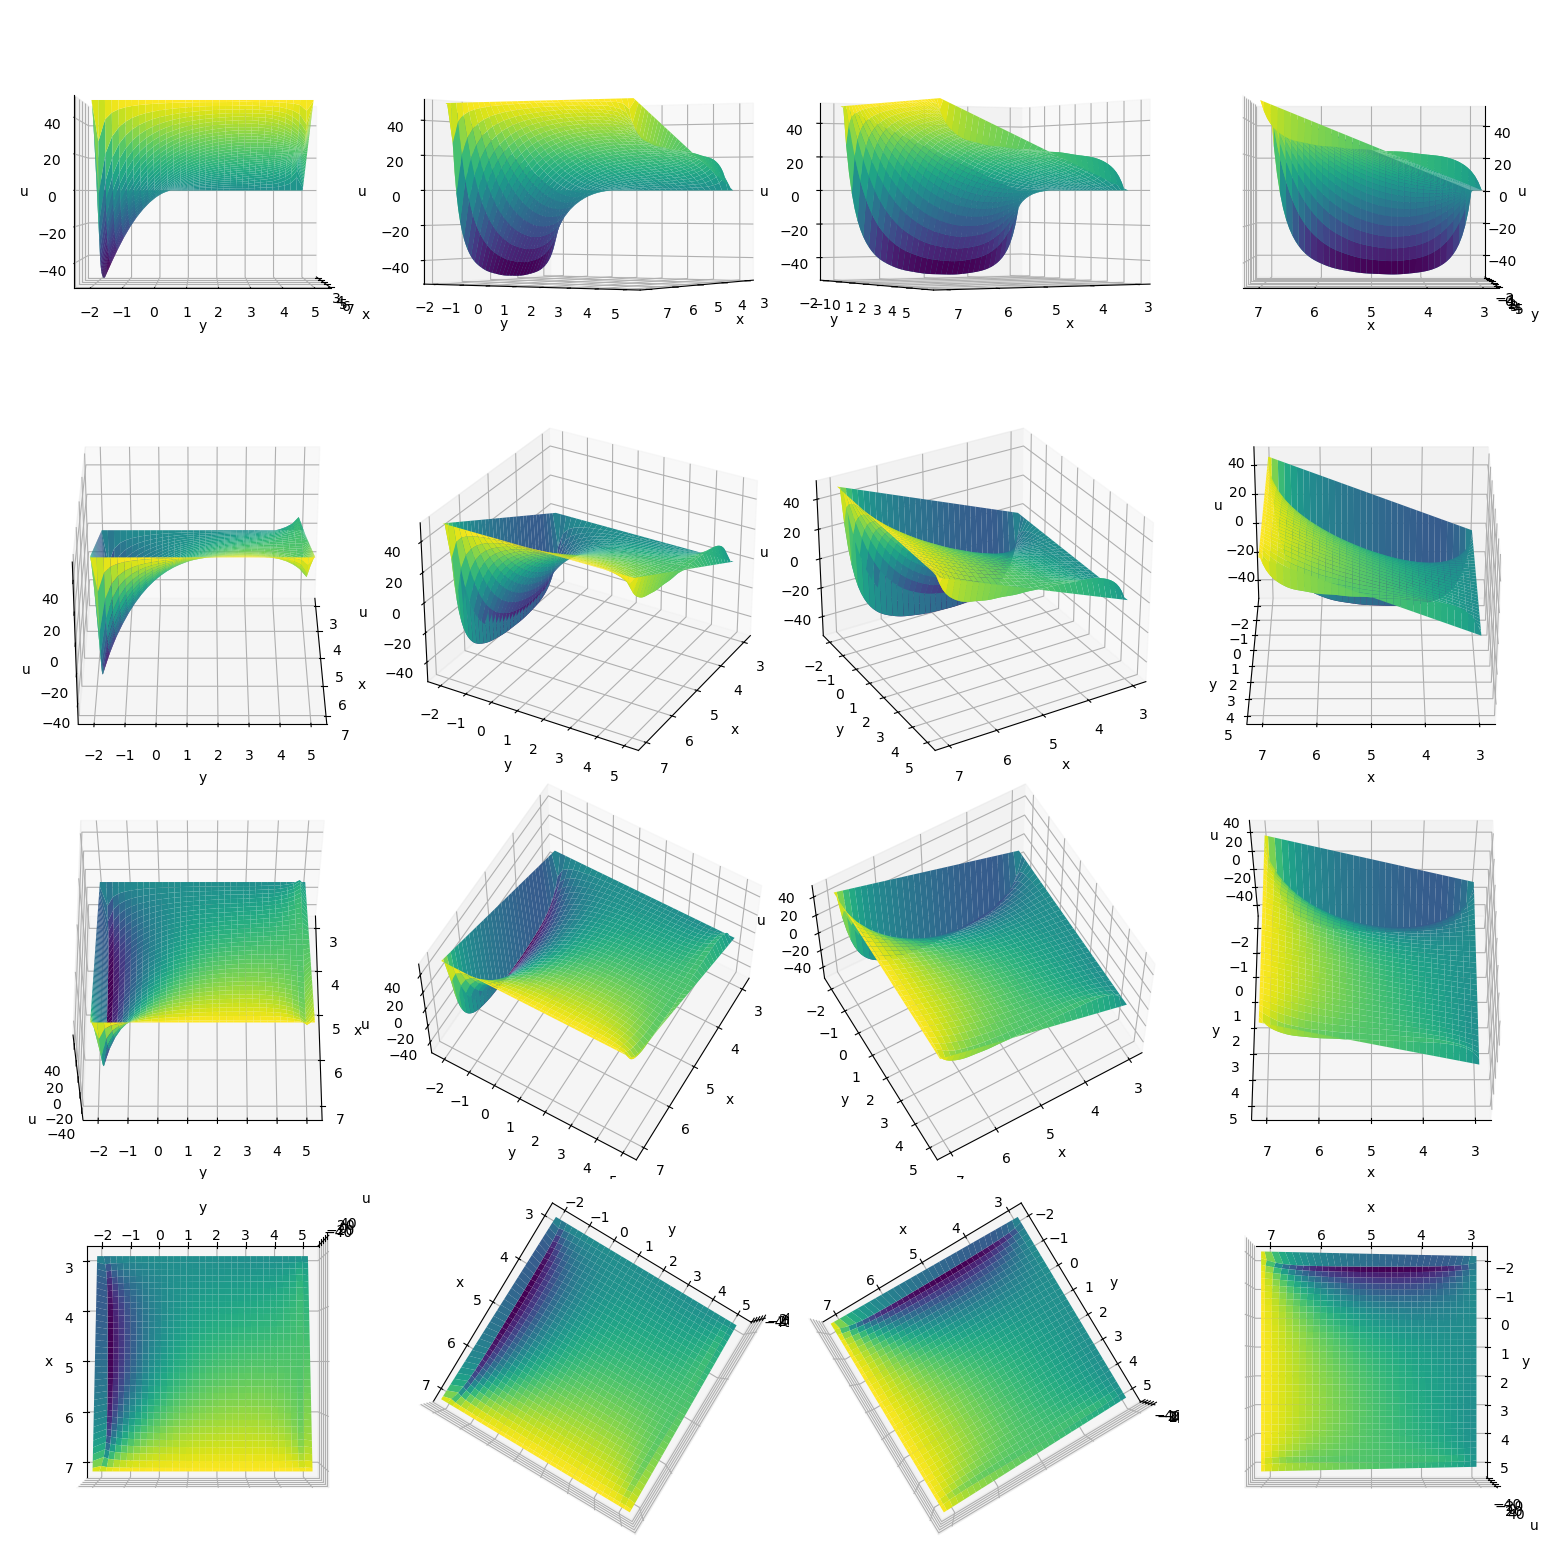

In [45]:

# If we want several perspectives:
perspective = [
    (0, 0), # first number is the elevation of the camera, 2nd is the angle wrt vertical axis
    (0, 30),
    (0, 60),
    (0, 90),
    (30, 0),
    (30, 30),
    (30, 60),
    (30, 90),
    (60, 0),
    (60, 30),
    (60, 60),
    (60, 90),
    (90, 0),
    (90, 30),
    (90, 60),
    (90, 90)
]

plot_surface_perspectives(X, Y, U, perspective)